### Library


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from google.colab import drive
drive.mount('/content/drive')
path_file = '/content/drive/MyDrive/Colab Notebooks/Smart Farming Sensor Data for Yield Prediction/Smart_Farming_Crop_Yield_2024.csv'

Mounted at /content/drive


### 1. input dataset

In [ ]:
df = pd.read_csv(path_file)
df

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,yield_kg_per_hectare,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,NaN,...,2024-01-08,2024-05-09,122,4408.07,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,5389.98,SENS0002,2024-04-21,16.613022,70.869009,0.58,NaN
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,2931.16,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,4227.80,SENS0004,2024-05-14,31.071298,85.519998,0.44,NaN
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,NaN,...,2024-02-05,2024-05-20,105,4979.96,SENS0005,2024-04-13,16.568540,81.691720,0.84,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,FARM0496,Central USA,Rice,42.85,6.70,30.85,52.35,79.58,7.25,Manual,...,2024-01-16,2024-06-02,138,4251.40,SENS0496,2024-05-08,30.386623,76.147700,0.59,Mild
496,FARM0497,North India,Soybean,34.22,6.75,17.46,256.23,45.14,5.78,NaN,...,2024-01-01,2024-04-14,104,3708.54,SENS0497,2024-01-19,18.832748,75.736924,0.85,Severe
497,FARM0498,North India,Cotton,15.93,5.72,17.03,288.96,57.87,7.69,Drip,...,2024-01-02,2024-05-09,128,2604.41,SENS0498,2024-04-20,23.262016,81.992230,0.71,Mild
498,FARM0499,Central USA,Soybean,38.61,6.20,17.08,279.06,73.09,9.60,Drip,...,2024-01-25,2024-06-04,131,2586.36,SENS0499,2024-03-02,19.764989,84.426869,0.77,Severe


### 2. choice Fitur (Sensor Lingkungan + Hasil Tanaman)

In [ ]:
# 1. kolom yg mau di analisa
fitur = ['soil_moisture_%', 'temperature_C', 'rainfall_mm', 'NDVI_index', 'yield_kg_per_hectare']
X = df[fitur].copy()

# 2. Karena satuannya berbeda-beda, jadi di samakan skalanya
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 3.Melatih Model Isolation Forest

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,harvest_date,total_days,yield_kg_per_hectare,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status,Status_Anomali
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,NaN,...,2024-05-09,122,4408.07,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild,1
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-05-26,112,5389.98,SENS0002,2024-04-21,16.613022,70.869009,0.58,NaN,1
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-06-26,144,2931.16,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild,1
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-07-04,134,4227.80,SENS0004,2024-05-14,31.071298,85.519998,0.44,NaN,1
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,NaN,...,2024-05-20,105,4979.96,SENS0005,2024-04-13,16.568540,81.691720,0.84,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,FARM0496,Central USA,Rice,42.85,6.70,30.85,52.35,79.58,7.25,Manual,...,2024-06-02,138,4251.40,SENS0496,2024-05-08,30.386623,76.147700,0.59,Mild,-1
496,FARM0497,North India,Soybean,34.22,6.75,17.46,256.23,45.14,5.78,NaN,...,2024-04-14,104,3708.54,SENS0497,2024-01-19,18.832748,75.736924,0.85,Severe,1
497,FARM0498,North India,Cotton,15.93,5.72,17.03,288.96,57.87,7.69,Drip,...,2024-05-09,128,2604.41,SENS0498,2024-04-20,23.262016,81.992230,0.71,Mild,1
498,FARM0499,Central USA,Soybean,38.61,6.20,17.08,279.06,73.09,9.60,Drip,...,2024-06-04,131,2586.36,SENS0499,2024-03-02,19.764989,84.426869,0.77,Severe,1


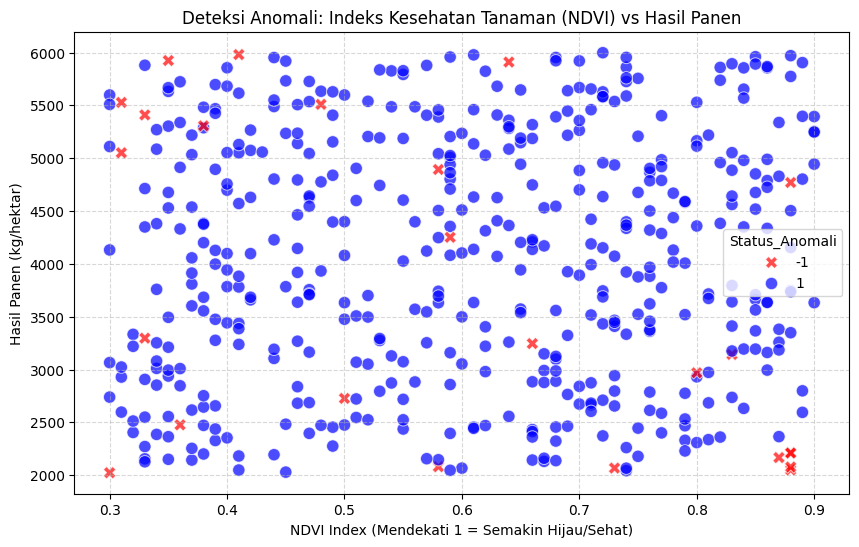

In [ ]:
# contamination=0.05 berarti algoritma akan mencari 5% data paling "aneh"
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df['Status_Anomali'] = model.fit_predict(X_scaled)
display(df)

# 5. Visualisasi Hasil
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='NDVI_index',
    y='yield_kg_per_hectare',
    hue='Status_Anomali',
    palette={1: 'blue', -1: 'red'},
    style='Status_Anomali',
    markers={1: 'o', -1: 'X'},
    s=80, alpha=0.7
)

plt.title('Deteksi Anomali: Indeks Kesehatan Tanaman (NDVI) vs Hasil Panen')
plt.xlabel('NDVI Index (Mendekati 1 = Semakin Hijau/Sehat)')
plt.ylabel('Hasil Panen (kg/hektar)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 4. Menampilkan Detail Data yg anomali

In [ ]:
anomali = df[df['Status_Anomali'] == -1]
print(f"\n[!] Ditemukan {len(anomali)} titik anomali.")
print("Contoh Data Anomali yang Terdeteksi:")
display(anomali[['farm_id', 'crop_type', 'NDVI_index', 'yield_kg_per_hectare', 'temperature_C', 'soil_moisture_%']])


[!] Ditemukan 25 titik anomali.
Contoh Data Anomali yang Terdeteksi:


,farm_id,crop_type,NDVI_index,yield_kg_per_hectare,temperature_C,soil_moisture_%
9,FARM0010,Rice,0.58,4893.41,16.18,10.25
28,FARM0029,Cotton,0.50,2726.92,33.39,35.35
31,FARM0032,Maize,0.88,2050.61,17.42,39.76
94,FARM0095,Wheat,0.83,3142.99,34.33,43.08
143,FARM0144,Maize,0.33,5409.69,22.95,39.75
180,FARM0181,Maize,0.58,2080.21,32.08,10.96
202,FARM0203,Rice,0.88,4770.06,31.30,34.21
212,FARM0213,Wheat,0.73,2067.56,20.04,12.56
214,FARM0215,Maize,0.87,2167.09,28.55,43.60
247,FARM0248,Soybean,0.88,2077.58,32.07,38.31


### 5. Deteksi Anomali(Terpisah per Jenis Tanaman)

 PROSES ISOLATION FOREST TERPISAH PER TANAMAN 

Tanaman: Wheat      | Total Data: 92   | Terdeteksi Anomali: 5
Tanaman: Soybean    | Total Data: 108  | Terdeteksi Anomali: 6
Tanaman: Maize      | Total Data: 111  | Terdeteksi Anomali: 6
Tanaman: Cotton     | Total Data: 107  | Terdeteksi Anomali: 6
Tanaman: Rice       | Total Data: 82   | Terdeteksi Anomali: 5


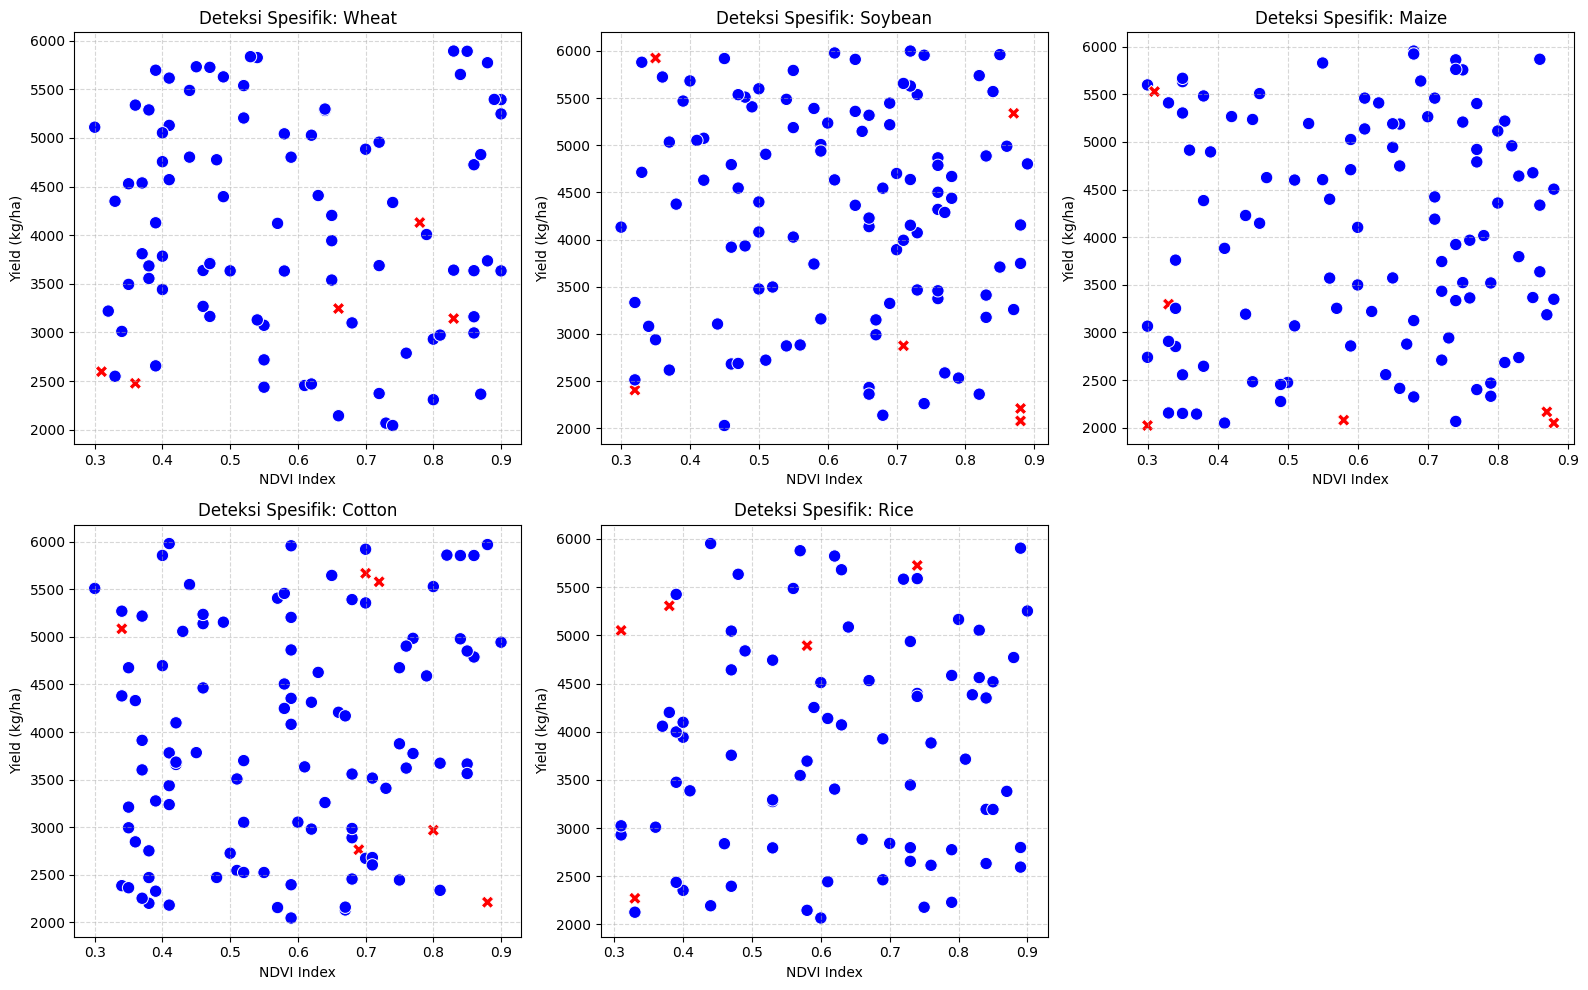

In [ ]:
# menggunakan fitur yang sama seperti sebelumnya
fitur = ['soil_moisture_%', 'temperature_C', 'rainfall_mm', 'NDVI_index', 'yield_kg_per_hectare']
df['Status_Anomali_Spesifik'] = 1

# Ambil daftar semua jenis tanaman  'crop_type'
macam_tanaman = df['crop_type'].unique()

# kanvas gambar besar untuk menampung banyak grafik sekaligus (2 baris, 3 kolom)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

print(" PROSES ISOLATION FOREST TERPISAH PER TANAMAN \n")

# Looping: Latih model HANYA untuk satu jenis tanaman dalam satu waktu
for i, tanaman in enumerate(macam_tanaman):

    # 1. Filter data khusus tanaman tertentu
    df_khusus = df[df['crop_type'] == tanaman].copy()
    X_khusus = df_khusus[fitur]

    # 2. Latih Isolation Forest KHUSUS untuk tanaman ini
    # (menggunakan StandardScaler di sini karena Isolation Forest kebal terhadap perbedaan skala)
    model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
    df_khusus['Status'] = model.fit_predict(X_khusus)

    # 3. meMasukkan hasil prediksinya kembali ke DataFrame utama
    df.loc[df['crop_type'] == tanaman, 'Status_Anomali_Spesifik'] = df_khusus['Status']

    # 4. Hitung dan print log jumlah anomali per tanaman
    jumlah_anomali = len(df_khusus[df_khusus['Status'] == -1])
    print(f"Tanaman: {tanaman:<10} | Total Data: {len(df_khusus):<4} | Terdeteksi Anomali: {jumlah_anomali}")

    # 5. grafik scatter plot di dalam kotak subplot yang sesuai
    sns.scatterplot(
        data=df_khusus, x='NDVI_index', y='yield_kg_per_hectare',
        hue='Status', palette={1: 'blue', -1: 'red'},
        style='Status', markers={1: 'o', -1: 'X'}, s=80, ax=axes[i], legend=False
    )
    axes[i].set_title(f'Deteksi Spesifik: {tanaman}')
    axes[i].set_xlabel('NDVI Index')
    axes[i].set_ylabel('Yield (kg/ha)')
    axes[i].grid(True, linestyle='--', alpha=0.5)

# Rapikan tampilan: Hapus kotak grafik yang kosong jika jumlah tanaman kurang dari 6
for j in range(len(macam_tanaman), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 6. Detail Data Anomali

In [ ]:
anomali_akurat = df[df['Status_Anomali_Spesifik'] == -1]

print("\n[+] Ditemukan total", len(anomali_akurat), "titik anomali setelah dipisah per tanaman.")
print("Contoh Anomali Kontekstual yang Ditemukan:")
display(anomali_akurat[['farm_id', 'crop_type', 'NDVI_index', 'yield_kg_per_hectare', 'temperature_C', 'soil_moisture_%']].head())


[+] Ditemukan total 28 titik anomali setelah dipisah per tanaman.
Contoh Anomali Kontekstual yang Ditemukan:


,farm_id,crop_type,NDVI_index,yield_kg_per_hectare,temperature_C,soil_moisture_%
9,FARM0010,Rice,0.58,4893.41,16.18,10.25
31,FARM0032,Maize,0.88,2050.61,17.42,39.76
66,FARM0067,Wheat,0.78,4130.33,19.22,10.27
74,FARM0075,Soybean,0.32,2404.56,18.61,22.66
82,FARM0083,Cotton,0.69,2764.41,30.82,11.29


### 7. STUDI KASUS TIME SERIES: Pemantauan Sensor Harian (1 Kebun)

=== MEMULAI ANALISIS TIME SERIES HARIAN ===



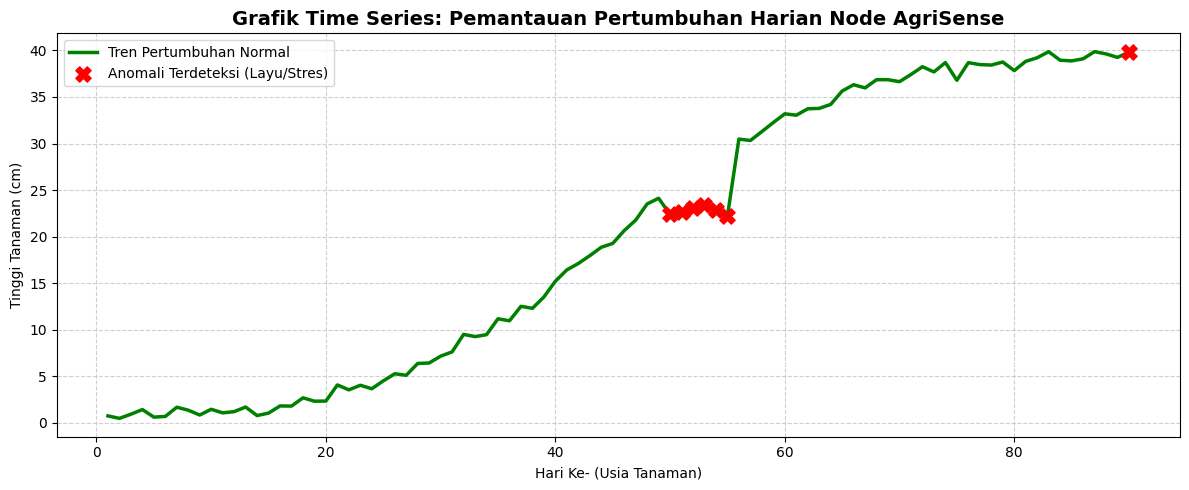


[!] PERINGATAN: Sistem IoT mendeteksi anomali pada waktu berikut:


,Tanggal,Hari_Ke,Kelembapan_%,Tinggi_cm
49,2026-06-19,50,16.25,22.38
50,2026-06-20,51,13.29,22.66
51,2026-06-21,52,12.86,23.04
52,2026-06-22,53,15.96,23.38
53,2026-06-23,54,14.55,22.84
54,2026-06-24,55,16.43,22.19
89,2026-07-29,90,78.60,39.82


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

print("=== MEMULAI ANALISIS TIME SERIES HARIAN ===\n")

# A. MEMBUAT SIMULASI DATA SENSOR HARIAN SELAMA 90 HARI
np.random.seed(42)
hari = np.arange(1, 91)
tanggal = pd.date_range(start='2026-05-01', periods=90, freq='D')

# Kurva pertumbuhan tanaman normal (Tinggi bertambah seiring waktu)
tinggi_tanaman = 40 / (1 + np.exp(-0.1 * (hari - 45))) + np.random.normal(0, 0.5, 90)
kelembapan = np.random.normal(65, 5, 90)

df_harian = pd.DataFrame({'Tanggal': tanggal, 'Hari_Ke': hari, 'Kelembapan_%': kelembapan, 'Tinggi_cm': tinggi_tanaman})

# B. MENYUNTIKKAN ANOMALI (Misal: Hari ke-50 sampai 55 Irigasi Rusak)
df_harian.loc[49:54, 'Kelembapan_%'] = np.random.normal(15, 2, 6) # Tanah tiba-tiba kering
df_harian.loc[49:54, 'Tinggi_cm'] = df_harian.loc[48, 'Tinggi_cm'] - np.random.normal(1.5, 0.5, 6) # Tanaman layu/menyusut

# C. DETEKSI ANOMALI TIME SERIES
fitur_harian = ['Hari_Ke', 'Kelembapan_%', 'Tinggi_cm']
X_harian = df_harian[fitur_harian]

# Melatih model khusus untuk data harian ini
model_harian = IsolationForest(n_estimators=100, contamination=0.07, random_state=42)
df_harian['Status_Anomali'] = model_harian.fit_predict(X_harian)

# D. VISUALISASI GRAFIK TIME SERIES (PERTUMBUHAN)
plt.figure(figsize=(12, 5))

# Plot garis pertumbuhan utama
sns.lineplot(data=df_harian, x='Hari_Ke', y='Tinggi_cm', color='green', linewidth=2.5, label='Tren Pertumbuhan Normal')

# TANDA titik anomali di garis waktu
anomali_harian = df_harian[df_harian['Status_Anomali'] == -1]
plt.scatter(anomali_harian['Hari_Ke'], anomali_harian['Tinggi_cm'], color='red', s=120, marker='X', zorder=5, label='Anomali Terdeteksi (Layu/Stres)')

plt.title('Grafik Time Series: Pemantauan Pertumbuhan Harian Node AgriSense', fontsize=14, fontweight='bold')
plt.xlabel('Hari Ke- (Usia Tanaman)')
plt.ylabel('Tinggi Tanaman (cm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# E. MENAMPILKAN LOG WAKTU KEJADIAN
print("\n[!] PERINGATAN: Sistem IoT mendeteksi anomali pada waktu berikut:")
display(anomali_harian[['Tanggal', 'Hari_Ke', 'Kelembapan_%', 'Tinggi_cm']].round(2))